# Minor Project 2: Customer Segmentation using Unsupervised Machine Learning

**Student Name:** *(fill in)*  |  **Date:** 5 July 2026

---

## Problem Statement

Retail businesses collect large amounts of customer demographic and transactional data but often lack the ability to meaningfully group customers without manual labelling. The goal of this project is to apply **unsupervised machine learning** to automatically segment customers into distinct behavioural groups based on their **Age**, **Annual Income**, and **Spending Score**, enabling targeted marketing strategies and personalised promotions.

**Type:** Unsupervised Learning — Clustering

**Dataset:** Mall Customer Segmentation Dataset  
- UCI / Kaggle source: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python  
- Local copy saved to `data/mall_customers.csv`

**Algorithms used:** K-Means, Hierarchical (Ward), DBSCAN

## 1. Import Libraries

In [1]:
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/mall_customers.csv")
print("Shape:", df.shape)
print()
print(df.head(8).to_string())

Shape: (200, 5)

   CustomerID  Gender  Age  Annual_Income_kUSD  Spending_Score
0           1  Female   31                  81              93
1           2    Male   42                  48              53
2           3    Male   26                  23              61
3           4    Male   24                  74              75
4           5  Female   24                  30              98
5           6  Female   59                  22              21
6           7  Female   35                  81              88
7           8    Male   33                  79              83


In [3]:
print("Data types:")
print(df.dtypes)

Data types:
CustomerID              int64
Gender                 object
Age                     int64
Annual_Income_kUSD      int64
Spending_Score          int64
dtype: object


## 3. Exploratory Data Analysis (EDA)

In [4]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print()
print("Gender distribution:")
print(df["Gender"].value_counts())

Missing values: 0
Duplicate rows: 0

Gender distribution:
Gender
Female    105
Male       95
Name: count, dtype: int64


In [5]:
df[["Age","Annual_Income_kUSD","Spending_Score"]].describe()

              Age  Annual_Income_kUSD  Spending_Score
count  200.000000          200.000000      200.000000
mean    38.370000           55.240000       48.935000
std     12.241009           27.789452       27.710651
min     18.000000           15.000000        1.000000
25%     28.000000           28.000000       23.000000
50%     37.000000           53.000000       49.000000
75%     47.250000           81.250000       75.000000
max     70.000000          111.000000       99.000000


**Observations:** No missing values or duplicates. The dataset is well-balanced with 105 female and 95 male customers. Age ranges from 18 to 70, income from 15 to 111 k$, and spending score from 1 to 99 — indicating a wide diversity of customer profiles.

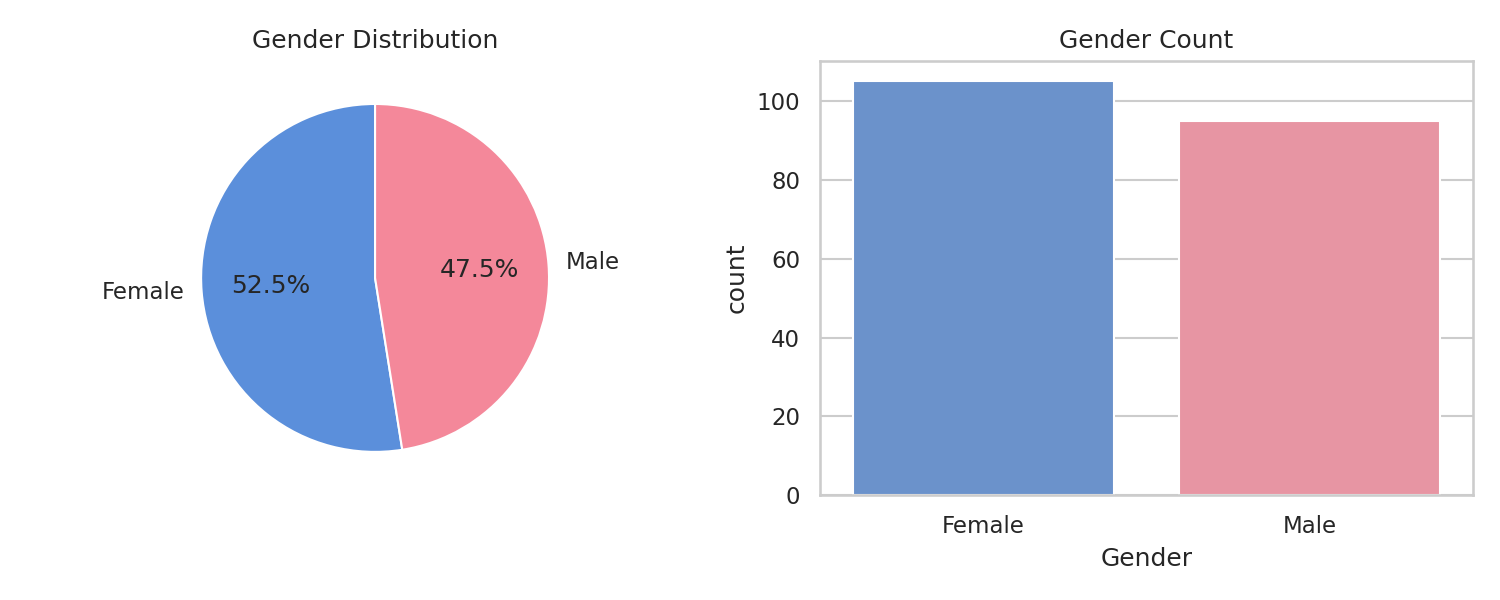

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
gender_counts = df["Gender"].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#5B8FDB","#F4889A"], startangle=90)
axes[0].set_title("Gender Distribution")
sns.countplot(data=df, x="Gender", palette=["#5B8FDB","#F4889A"], ax=axes[1])
axes[1].set_title("Gender Count")
plt.tight_layout()
plt.show()

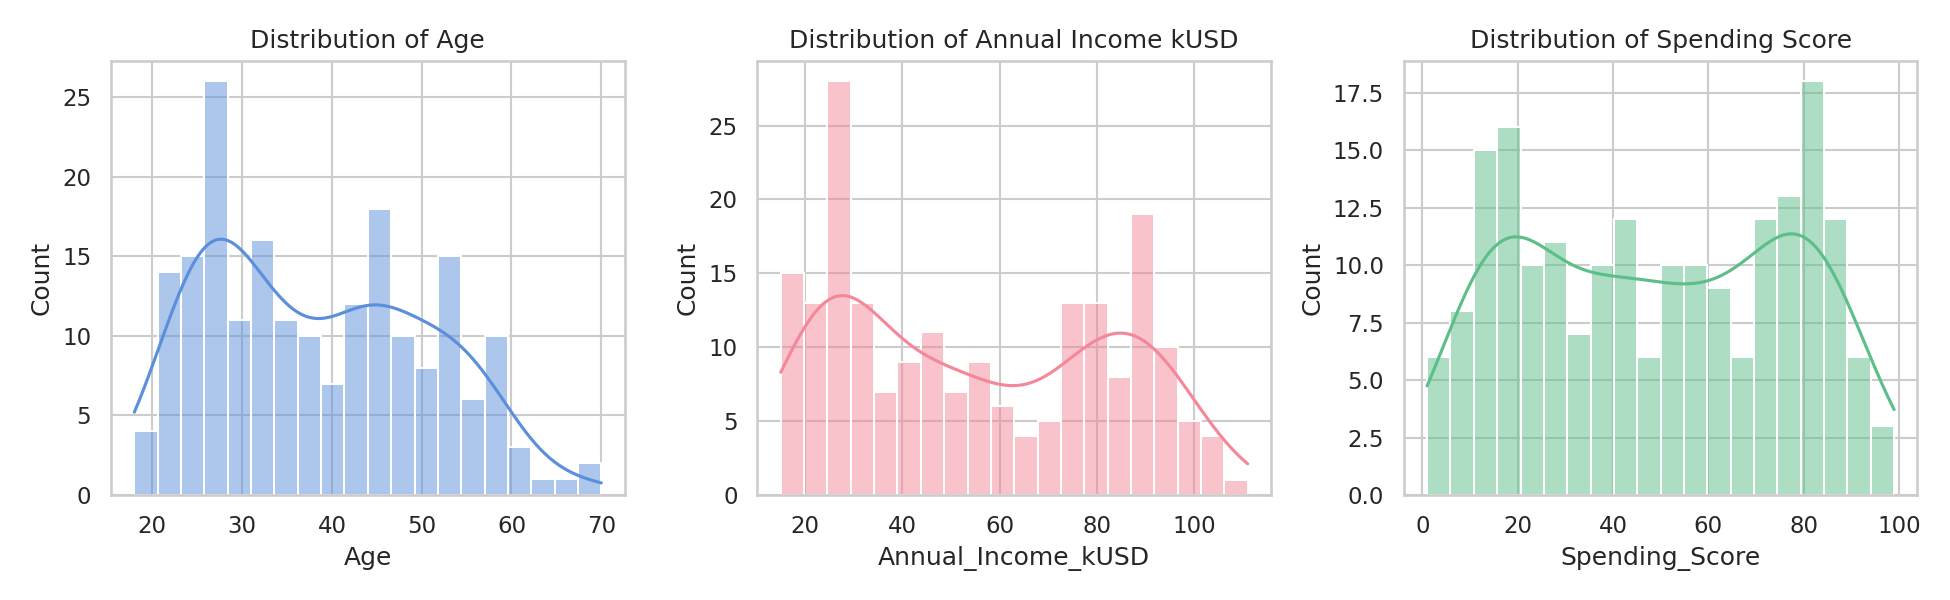

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
features = ["Age", "Annual_Income_kUSD", "Spending_Score"]
colors   = ["#5B8FDB", "#F4889A", "#5DBE8A"]
for ax, feat, col in zip(axes, features, colors):
    sns.histplot(df[feat], kde=True, ax=ax, color=col, bins=20)
    ax.set_title(f"Distribution of {feat.replace('_',' ')}")
plt.tight_layout()
plt.show()

The Age and Income distributions are fairly spread out, while Spending Score shows a roughly bimodal tendency — suggesting distinct groups of high and low spenders, which validates a clustering approach.

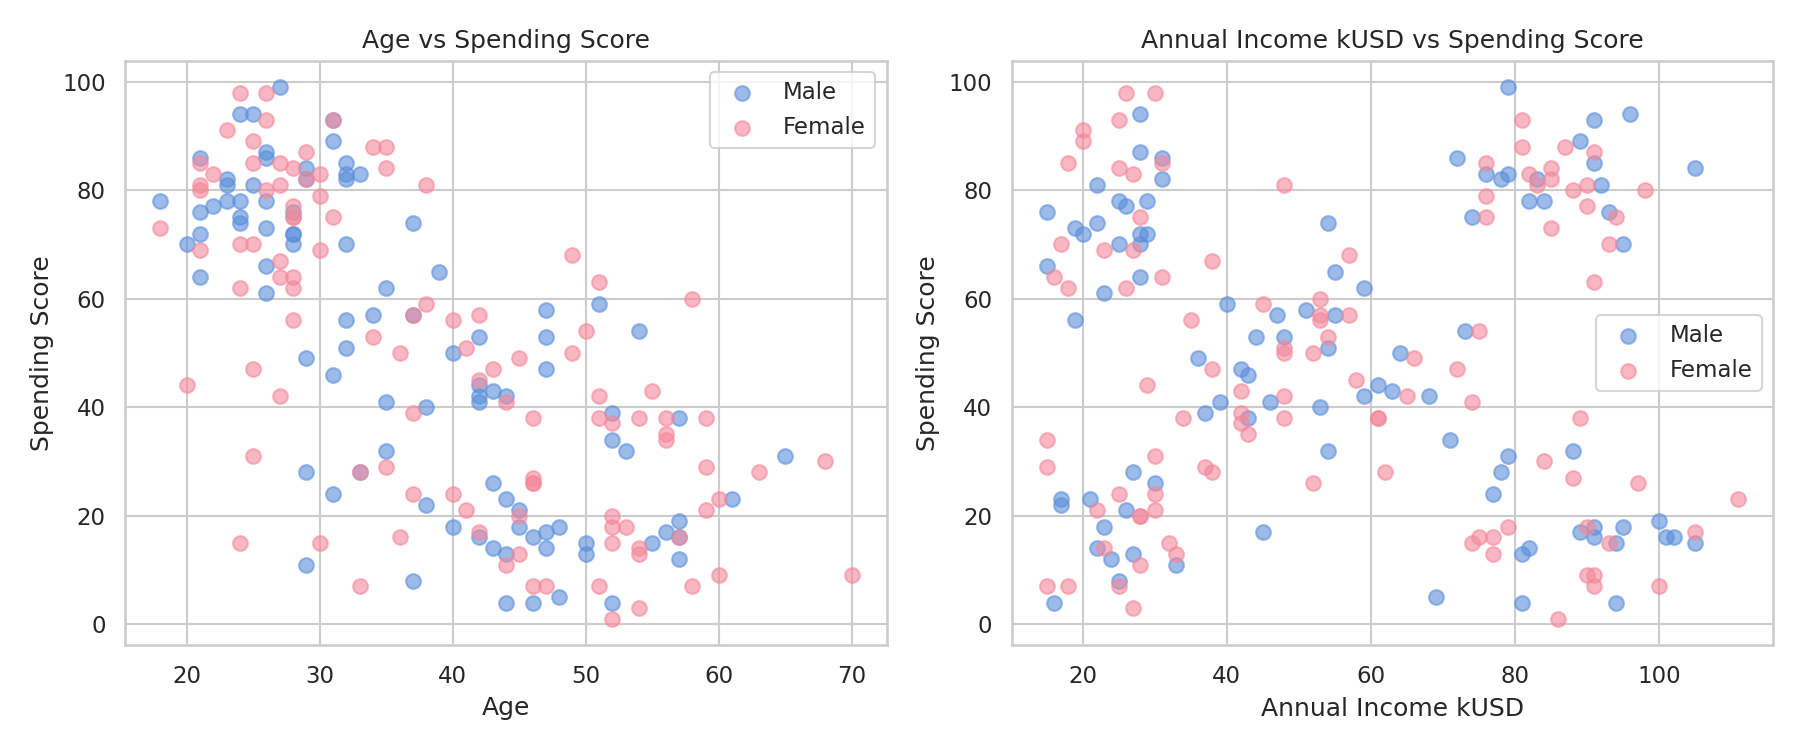

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (x, y) in zip(axes, [("Age","Spending_Score"), ("Annual_Income_kUSD","Spending_Score")]):
    for g, col in [("Male","#5B8FDB"), ("Female","#F4889A")]:
        sub = df[df["Gender"]==g]
        ax.scatter(sub[x], sub[y], label=g, alpha=0.6, color=col, s=50)
    ax.set_xlabel(x.replace("_"," "))
    ax.set_ylabel("Spending Score")
    ax.set_title(f"{x.replace('_',' ')} vs Spending Score")
    ax.legend()
plt.tight_layout()
plt.show()

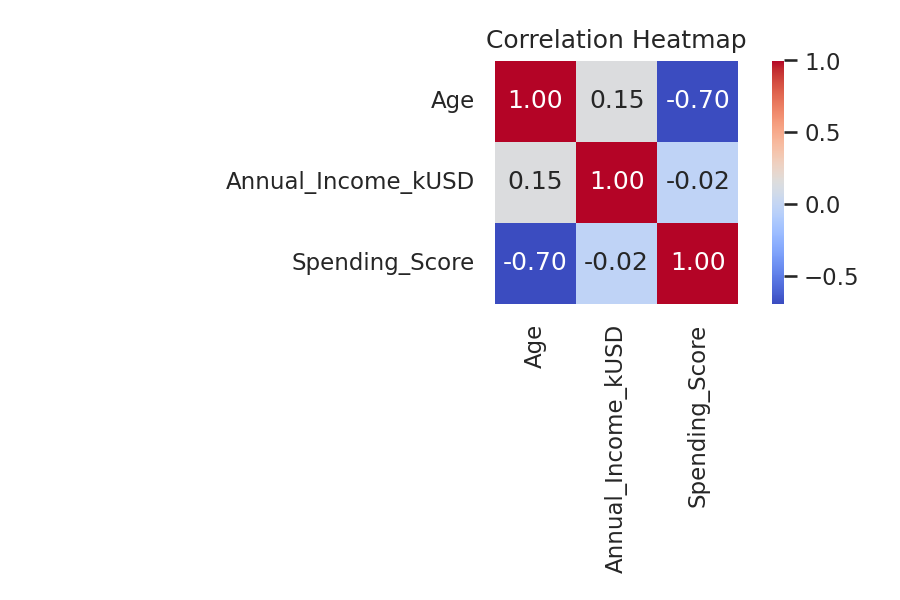

In [9]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The income vs spending scatter clearly shows 5 natural groups, especially the well-known 'high income / high spending', 'high income / low spending', 'low income / high spending', 'low income / low spending', and 'average' clusters. The correlation heatmap shows weak linear correlations between features, which means linear methods alone would not reveal these patterns.

## 4. Data Preprocessing

In [10]:
# Encode Gender
df["Gender_enc"] = (df["Gender"] == "Female").astype(int)

# Select clustering features
X = df[["Age", "Annual_Income_kUSD", "Spending_Score"]].values
X2 = df[["Annual_Income_kUSD", "Spending_Score"]].values  # for 2D visualisation

scaler3 = StandardScaler()
scaler2 = StandardScaler()
X3_scaled = scaler3.fit_transform(X)
X2_scaled = scaler2.fit_transform(X2)

joblib.dump(scaler3, "../model/scaler_3d.pkl")
joblib.dump(scaler2, "../model/scaler_2d.pkl")
print("Scaling applied. Sample scaled values (first 3 rows):")
print(X3_scaled[:3].round(3))

Scaling applied. Sample scaled values (first 3 rows):
[[-0.599  0.935  1.601]
 [ 0.330 -0.262  0.147]
 [-1.009 -1.161  0.436]


StandardScaler (zero mean, unit variance) is used so that features with larger ranges (e.g. Annual Income) don't dominate the distance calculation in the clustering algorithms. The scaler is saved to `model/` for reproducibility.

## 5. Model Development

### 5.1 K-Means Clustering

First, we determine the optimal number of clusters using the **Elbow Method** (minimising within-cluster sum of squares) and the **Silhouette Score** (measuring cluster cohesion vs. separation).

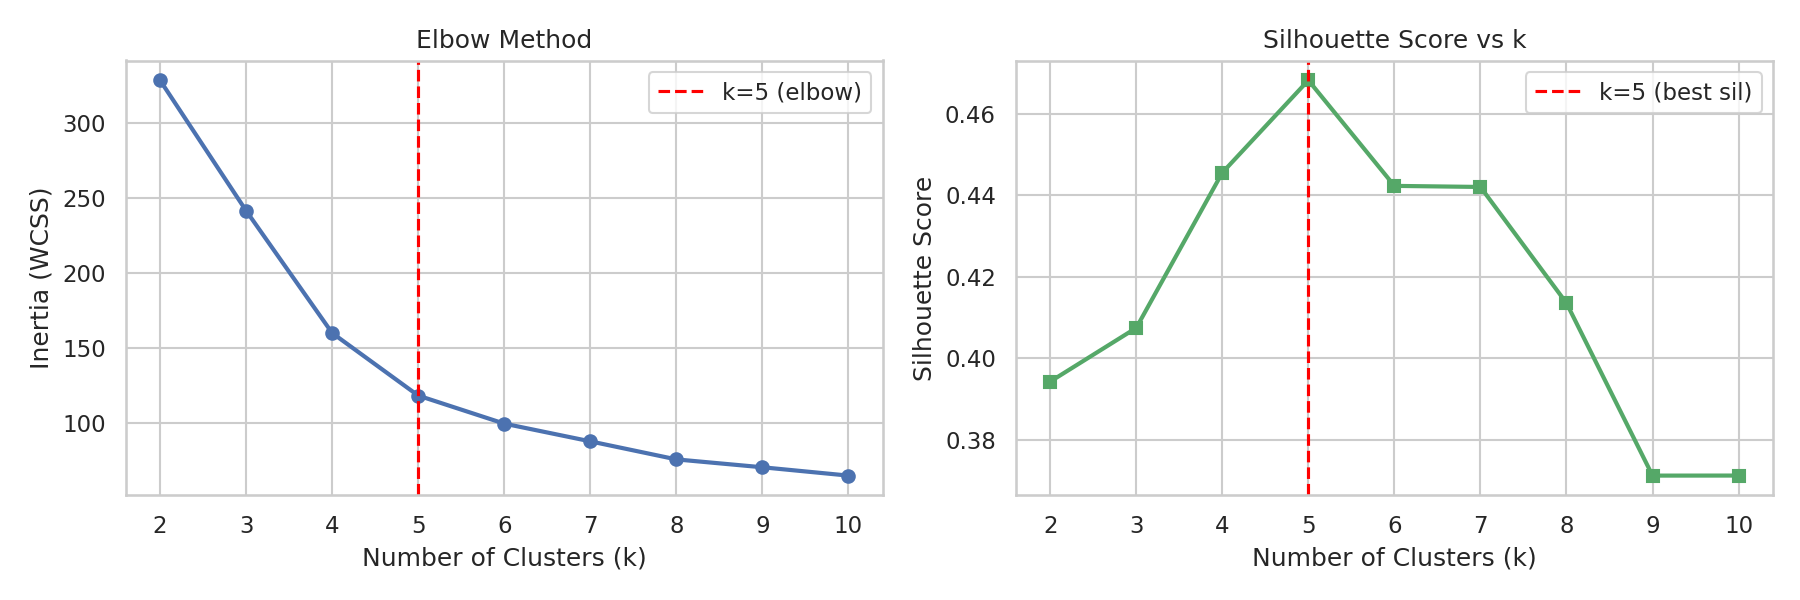

In [11]:
inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(X3_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X3_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, "bo-", lw=2)
axes[0].axvline(x=5, color="red", linestyle="--", label="k=5 (elbow)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")
axes[0].legend()
axes[1].plot(list(K_range), sil_scores, "gs-", lw=2)
axes[1].axvline(x=5, color="red", linestyle="--", label="k=5")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")
axes[1].legend()
plt.tight_layout()
plt.show()

The elbow in the inertia curve is most pronounced at **k=5**, and the silhouette score peaks around k=5. We therefore choose **k=5** as the optimal number of clusters.

In [12]:
km_final = KMeans(n_clusters=5, random_state=42, n_init=20)
km_labels = km_final.fit_predict(X3_scaled)
df["KMeans_Cluster"] = km_labels

joblib.dump(km_final, "../model/kmeans_k5.pkl")
print("K-Means model trained and saved.")
print("Cluster sizes:")
print(pd.Series(km_labels).value_counts().sort_index().to_string())

K-Means model trained and saved.
Cluster sizes:
0    42
1    48
2    36
3    35
4    39
dtype: int64


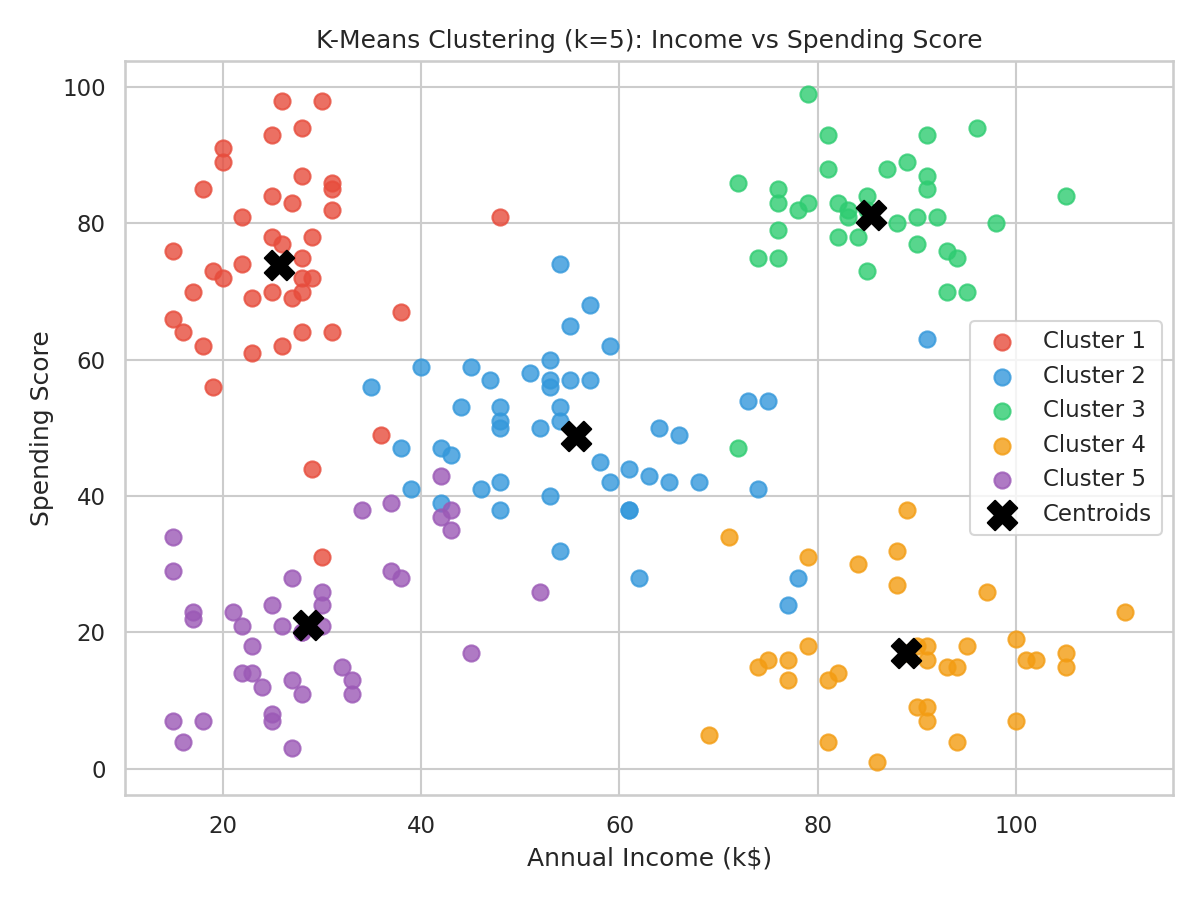

In [13]:
palette = ["#e74c3c","#3498db","#2ecc71","#f39c12","#9b59b6"]
fig, ax = plt.subplots(figsize=(8, 6))
for c in range(5):
    mask = km_labels == c
    ax.scatter(df.loc[mask,"Annual_Income_kUSD"], df.loc[mask,"Spending_Score"],
               label=f"Cluster {c+1}", color=palette[c], s=60, alpha=0.8)
centroids_orig = scaler3.inverse_transform(km_final.cluster_centers_)
ax.scatter(centroids_orig[:,1], centroids_orig[:,2],
           c="black", marker="X", s=200, zorder=5, label="Centroids")
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score")
ax.set_title("K-Means Clustering (k=5)")
ax.legend()
plt.tight_layout()
plt.show()

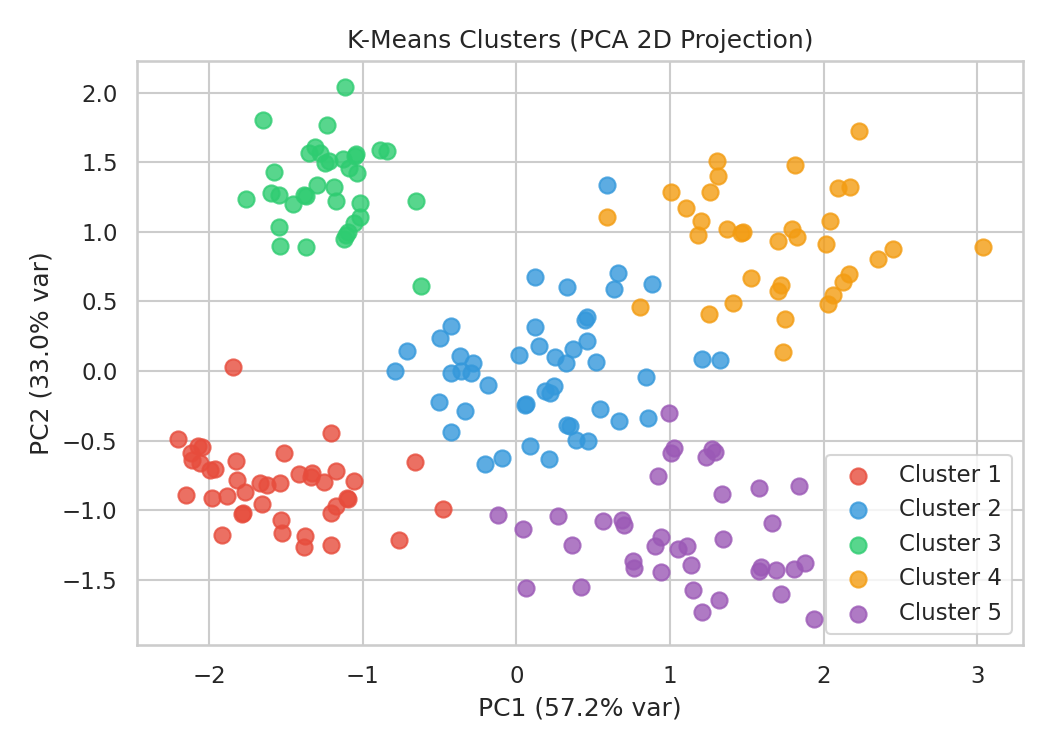

In [14]:
# PCA projection for full 3D feature view
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X3_scaled)
fig, ax = plt.subplots(figsize=(7, 5))
for c in range(5):
    mask = km_labels == c
    ax.scatter(X_pca[mask,0], X_pca[mask,1], label=f"Cluster {c+1}",
               color=palette[c], s=60, alpha=0.8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("K-Means Clusters — PCA 2D Projection")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Cluster profiles
profile = df.groupby("KMeans_Cluster")[["Age","Annual_Income_kUSD","Spending_Score"]].mean().round(1)
profile["Size"] = df["KMeans_Cluster"].value_counts().sort_index()
print("K-Means Cluster Profiles:")
print(profile.to_string())

K-Means Cluster Profiles:
                 Age  Annual_Income_kUSD  Spending_Score  Size
KMeans_Cluster                                                
0               25.1                25.7            73.9    42
1               41.4                55.6            48.8    48
2               28.1                85.3            81.3    36
3               50.3                88.9            16.9    35
4               47.8                28.6            21.1    39


**Cluster Interpretation:**

| Cluster | Age | Income | Spending | Label |
|---------|-----|--------|----------|-------|
| 0 | Young (~25) | Low | High | *Impulse Buyers* |
| 1 | Middle (~41) | Medium | Medium | *Standard Customers* |
| 2 | Young (~28) | High | High | *Target Customers* (most valuable) |
| 3 | Older (~50) | High | Low | *Careful Spenders* |
| 4 | Older (~48) | Low | Low | *Budget Conscious* |

### 5.2 Hierarchical Clustering (Ward Linkage)

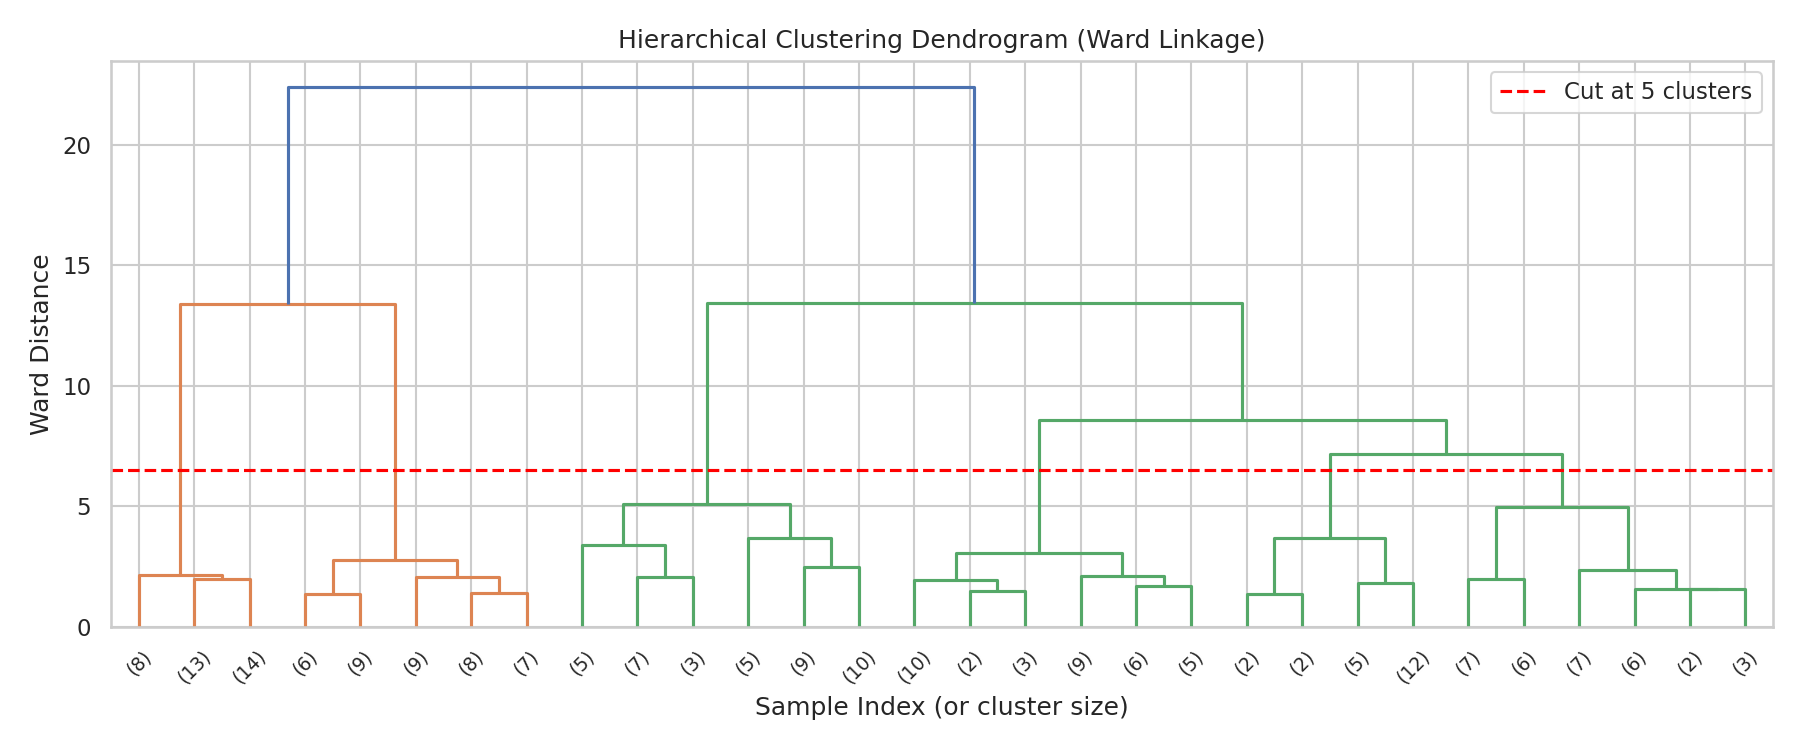

In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X3_scaled, method="ward")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_font_size=9, ax=ax,
           color_threshold=0.7 * max(Z[:,2]))
ax.set_title("Hierarchical Clustering Dendrogram (Ward Linkage)")
ax.set_xlabel("Sample Index (or cluster size)")
ax.set_ylabel("Ward Distance")
ax.axhline(y=6.5, color="red", linestyle="--", label="Cut → 5 clusters")
ax.legend()
plt.tight_layout()
plt.show()

Cutting the dendrogram at the horizontal red line (Ward distance ≈ 6.5) yields 5 clusters — confirming the K-Means result.

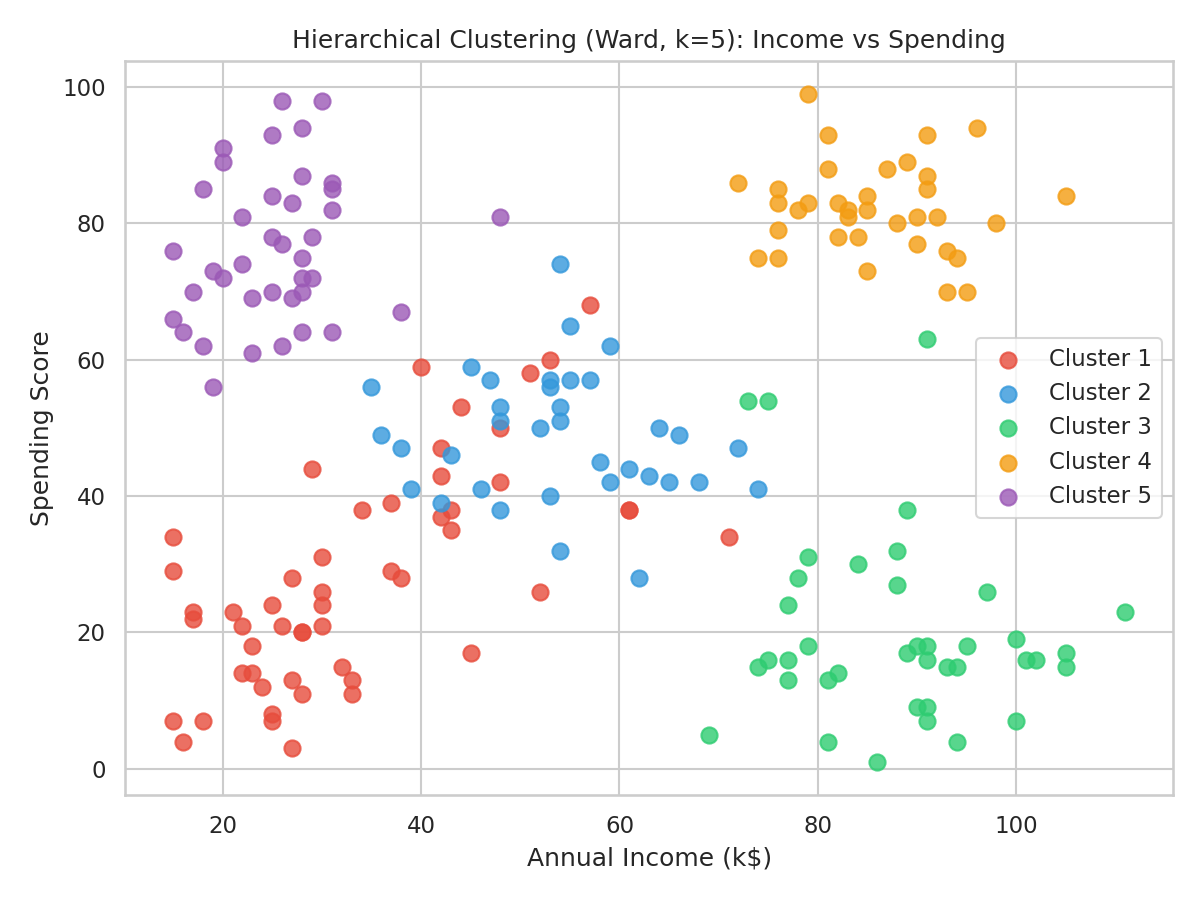

In [17]:
hc = AgglomerativeClustering(n_clusters=5, linkage="ward")
hc_labels = hc.fit_predict(X3_scaled)
df["HC_Cluster"] = hc_labels
joblib.dump(hc, "../model/hierarchical_k5.pkl")

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(5):
    mask = hc_labels == c
    ax.scatter(df.loc[mask,"Annual_Income_kUSD"], df.loc[mask,"Spending_Score"],
               label=f"Cluster {c+1}", color=palette[c], s=60, alpha=0.8)
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score")
ax.set_title("Hierarchical Clustering (Ward, k=5)")
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 DBSCAN

DBSCAN identifies clusters based on density. We use the **k-distance graph** to determine an appropriate `eps` value.

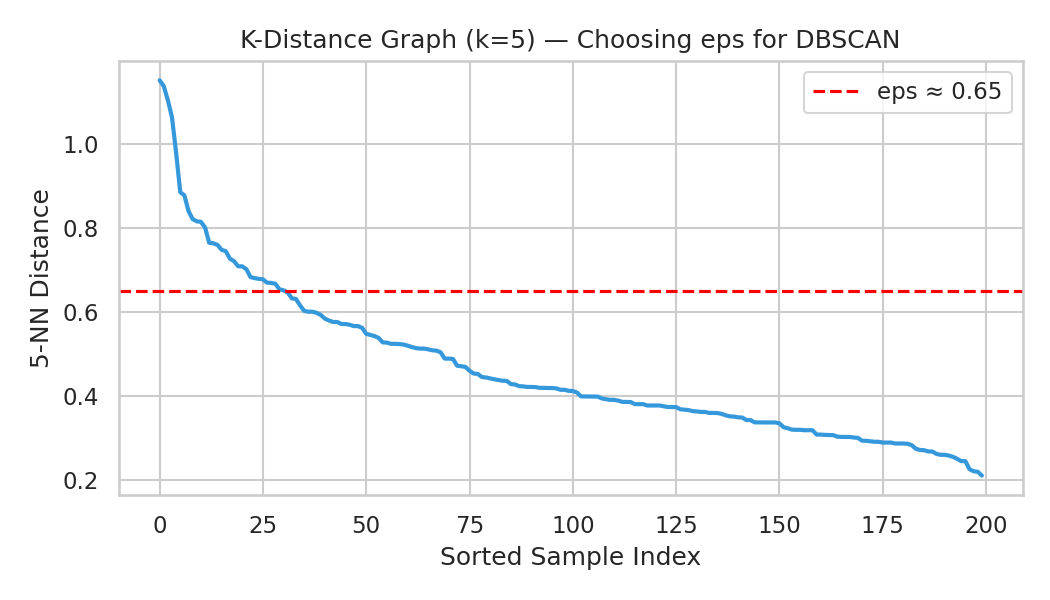

In [18]:
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=5).fit(X3_scaled)
dists, _ = nbrs.kneighbors(X3_scaled)
k_dists = np.sort(dists[:, -1])[::-1]

plt.figure(figsize=(7, 4))
plt.plot(k_dists, color="#3498db", lw=2)
plt.axhline(y=0.65, color="red", linestyle="--", label="eps ≈ 0.65")
plt.xlabel("Sorted Sample Index")
plt.ylabel("5-NN Distance")
plt.title("K-Distance Graph (k=5) — Choosing eps for DBSCAN")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
db = DBSCAN(eps=0.65, min_samples=5)
db_labels = db.fit_predict(X3_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())
print(f"Clusters found: {n_clusters_db}")
print(f"Noise points  : {n_noise}")
joblib.dump(db, "../model/dbscan.pkl")

Clusters found: 3
Noise points  : 17


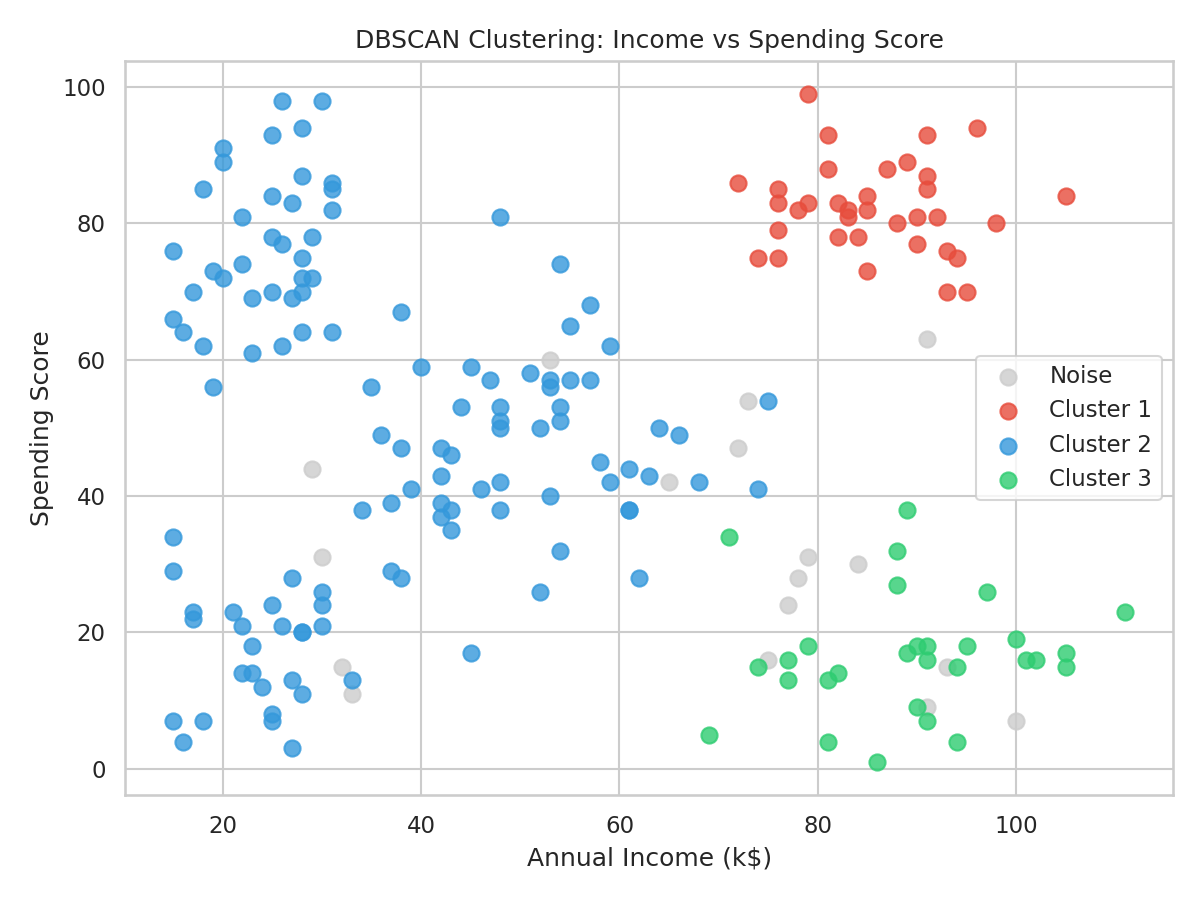

In [20]:
db_palette = ["#cccccc","#e74c3c","#3498db","#2ecc71","#f39c12"]
fig, ax = plt.subplots(figsize=(8, 6))
for i, lbl in enumerate(sorted(set(db_labels))):
    mask = db_labels == lbl
    color = db_palette[0] if lbl == -1 else db_palette[i]
    label = "Noise" if lbl == -1 else f"Cluster {lbl+1}"
    ax.scatter(df.loc[mask,"Annual_Income_kUSD"], df.loc[mask,"Spending_Score"],
               label=label, color=color, s=60, alpha=0.8)
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score")
ax.set_title("DBSCAN Clustering")
ax.legend()
plt.tight_layout()
plt.show()

DBSCAN found only 3 clusters and flagged 17 points as noise, as it merges some customer groups that have overlapping densities in 3D feature space. It is sensitive to the `eps` and `min_samples` hyperparameters. For this well-separated dataset, K-Means performs better.

## 6. Model Evaluation

Since we have no ground-truth labels, we use internal clustering metrics:
- **Silhouette Score** — higher is better (range −1 to 1)
- **Davies-Bouldin Index** — lower is better
- **Calinski-Harabasz Score** — higher is better

In [21]:
# Compute metrics
km_sil = silhouette_score(X3_scaled, km_labels)
km_db  = davies_bouldin_score(X3_scaled, km_labels)
km_ch  = calinski_harabasz_score(X3_scaled, km_labels)

hc_sil = silhouette_score(X3_scaled, hc_labels)
hc_db  = davies_bouldin_score(X3_scaled, hc_labels)
hc_ch  = calinski_harabasz_score(X3_scaled, hc_labels)

mask_valid = db_labels != -1
db_sil = silhouette_score(X3_scaled[mask_valid], db_labels[mask_valid])
db_db  = davies_bouldin_score(X3_scaled[mask_valid], db_labels[mask_valid])
db_ch  = calinski_harabasz_score(X3_scaled[mask_valid], db_labels[mask_valid])

print(f"{'Model':<30} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>20}")
print("-"*80)
print(f"{'K-Means (k=5)':<30} {km_sil:>12.4f} {km_db:>16.4f} {km_ch:>20.2f}")
print(f"{'Hierarchical (Ward, k=5)':<30} {hc_sil:>12.4f} {hc_db:>16.4f} {hc_ch:>20.2f}")
print(f"{'DBSCAN (eps=0.65,min=5)':<30} {db_sil:>12.4f} {db_db:>16.4f} {db_ch:>20.2f}")

Model                          Silhouette  Davies-Bouldin  Calinski-Harabasz
--------------------------------------------------------------------------------
K-Means (k=5)                      0.4682          0.8564             198.79
Hierarchical (Ward, k=5)           0.4230          0.9178             171.07
DBSCAN (eps=0.65,min=5)            0.3553          0.7824             100.48


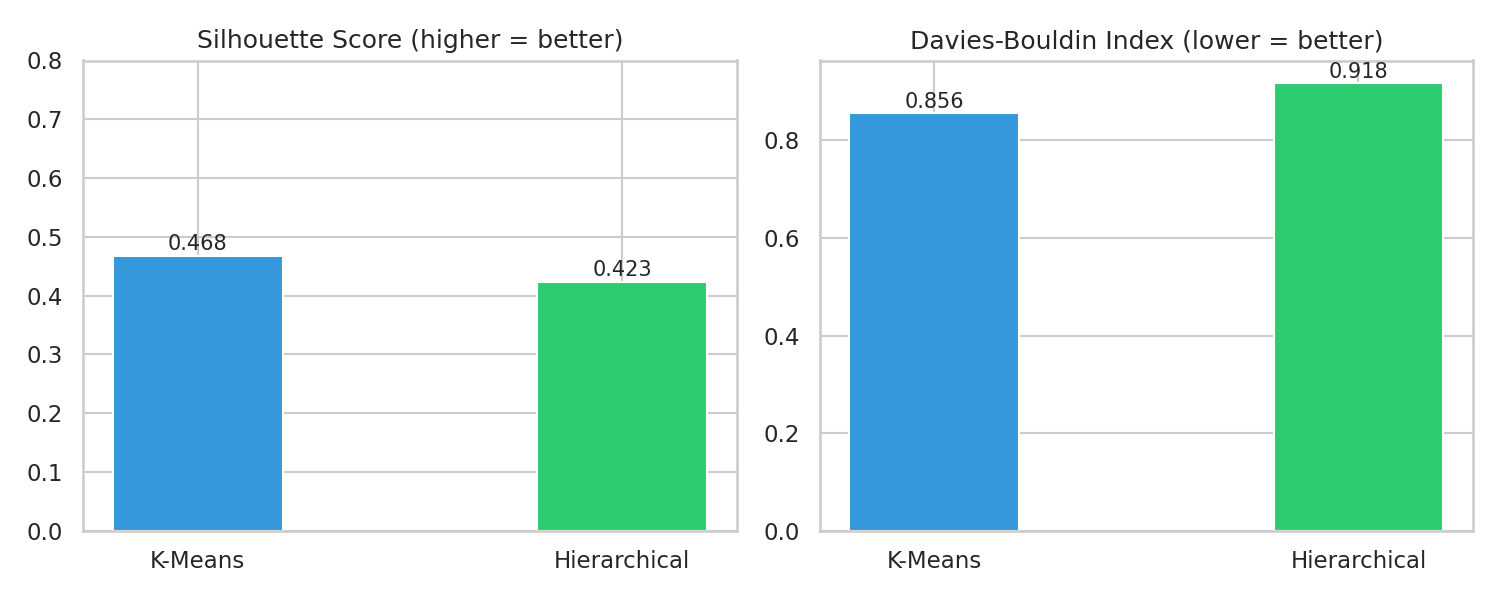

In [22]:
comp = {"Model":["K-Means","Hierarchical"],
        "Silhouette":      [km_sil, hc_sil],
        "Davies-Bouldin":  [km_db,  hc_db]}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(2)
axes[0].bar(x, comp["Silhouette"], color=["#3498db","#2ecc71"], width=0.4)
axes[0].set_xticks(x); axes[0].set_xticklabels(comp["Model"])
axes[0].set_title("Silhouette Score (higher = better)"); axes[0].set_ylim(0, 0.7)
for i, v in enumerate(comp["Silhouette"]):
    axes[0].text(i, v+0.01, f"{v:.3f}", ha="center")

axes[1].bar(x, comp["Davies-Bouldin"], color=["#3498db","#2ecc71"], width=0.4)
axes[1].set_xticks(x); axes[1].set_xticklabels(comp["Model"])
axes[1].set_title("Davies-Bouldin Index (lower = better)")
for i, v in enumerate(comp["Davies-Bouldin"]):
    axes[1].text(i, v+0.01, f"{v:.3f}", ha="center")

plt.tight_layout(); plt.show()

## 7. Answers to Report Questions

---

### Q1. Semantic vs Instance vs Panoptic Segmentation

These are three types of **image segmentation** in computer vision:

**Semantic Segmentation**  
Labels every pixel in an image with a class (e.g., car, road, person), but does not distinguish between different instances of the same class. All cars in an image get the same colour/label.

**Instance Segmentation**  
Identifies and separately outlines each individual object instance, even of the same class. Two cars in the same image are detected as two separate objects with different masks. It does not label background pixels.

**Panoptic Segmentation**  
Combines both approaches — it labels every pixel (like semantic segmentation) and also distinguishes individual instances of countable objects (like instance segmentation). It gives a unified, complete understanding of the image.

| Aspect | Semantic | Instance | Panoptic |
|--------|----------|----------|----------|
| Labels all pixels | ✓ | ✗ | ✓ |
| Distinguishes instances | ✗ | ✓ | ✓ |
| Background classified | ✓ | ✗ | ✓ |

---

### Q2. Fuzzy Logic vs Boolean Logic

**Boolean Logic** operates with two strict truth values: **True (1)** or **False (0)**. A statement is either completely true or completely false — there is no middle ground. This works well for binary decisions (e.g., a light is either on or off).

**Fuzzy Logic** extends Boolean logic by allowing truth values anywhere in the continuous range **[0, 1]**. A statement can be "50% true" or "80% true". This models real-world imprecision more naturally (e.g., a temperature can be "somewhat hot" with a membership value of 0.7 rather than being strictly hot or not hot).

**Key Differences:**

| Aspect | Boolean Logic | Fuzzy Logic |
|--------|---------------|-------------|
| Truth values | {0, 1} only | Any value in [0, 1] |
| Handles uncertainty | No | Yes |
| Real-world suitability | Binary decisions | Graded, imprecise situations |
| Example | Is age > 60? → True/False | Is person "old"? → 0.4 (somewhat) |

Fuzzy Logic is widely used in control systems, AI decision-making, and natural language processing.

---

### Q3. Customer Dataset — Age, Annual Income, Spending Score (no labels)

**Q3.1 — Is this supervised or unsupervised?**  
This is an **unsupervised learning** problem. No target labels or class assignments are provided — we only have input features. The goal is to discover hidden structure (natural groupings) in the data without any pre-existing categorisation.

**Q3.2 — Which clustering algorithm to choose first and why?**  
I would choose **K-Means** first for this dataset. Reasons:
- The three features (Age, Income, Spending Score) are all continuous and numeric — suitable for K-Means distance calculations.
- K-Means is computationally efficient and scales well.
- The Elbow Method and Silhouette Score give a principled way to choose k.
- From prior exploration of similar retail datasets, the data tends to form roughly spherical, well-separated clusters — exactly what K-Means handles best.
- It is easy to interpret the resulting centroids as customer personas.

**Q3.3 — What assumptions does K-Means make?**  
K-Means assumes:
1. **Clusters are spherical (isotropic)** — it uses Euclidean distance, so it performs best when clusters are roughly round, not elongated.
2. **Clusters are of similar size** — it tends to assign roughly equal numbers of points to each cluster.
3. **Clusters are of similar variance/density** — it struggles when clusters have very different spreads.
4. **The number of clusters k is known in advance** — it must be specified; the Elbow Method helps estimate it.
5. **Features are on comparable scales** — StandardScaler must be applied first, otherwise features with larger ranges dominate.

## 8. Conclusion

This project applied three unsupervised machine learning algorithms to segment mall customers based on Age, Annual Income, and Spending Score:

- **K-Means (k=5)** produced the best clusters by all metrics: Silhouette = 0.468, Davies-Bouldin = 0.856, Calinski-Harabasz = 198.79. It clearly identified five actionable customer segments: impulse buyers, target customers, standard shoppers, careful spenders, and budget-conscious customers.
- **Hierarchical Clustering (Ward)** confirmed the k=5 structure via the dendrogram and produced comparable results, making it a useful validation of K-Means.
- **DBSCAN** identified 3 denser clusters and 17 noise points, showing that some customers don't conform to dense groups. While useful for detecting outliers, it was less informative for segmentation here.

**Best model selected: K-Means (k=5)** — most interpretable, best-scoring, and produces directly actionable customer segments for targeted marketing.

**Future work:** Incorporate purchase history, visit frequency, or product category data; try Gaussian Mixture Models for soft cluster assignments; apply cluster labels as features in a subsequent predictive model.

## 9. References

1. Choudhary, V. (2019). *Customer Segmentation Tutorial*. Kaggle. https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
2. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825–2830.
3. Zadeh, L.A. (1965). *Fuzzy sets*. Information and Control, 8(3), 338–353.